# Case d dt=0.05


 TRAINING CASE D 
1 total 3.5977094314511904 sup 1.0081233721412526 phys 1.2947162021380956
100 total 0.004103741197156596 sup 0.0007007486643783835 phys 0.001624809918136856
200 total 0.003226956850249106 sup 0.0005479628213928217 phys 0.0012628500343444466
300 total 0.0026838087132168495 sup 0.00042890807696932553 phys 0.0010508361865404871
400 total 0.0022076955126067426 sup 0.0003366885563304765 phys 0.000858917199918389
500 total 0.0018019477799834536 sup 0.0002761214897954067 phys 0.0006863511975985541
600 total 0.0014800190974635842 sup 0.00021851376814508263 phys 0.0005542130421264319
700 total 0.001377041915758788 sup 0.00020085149212063338 phys 0.000511576221711385
800 total 0.0010817819500625837 sup 0.00014801233655727835 phys 0.0003903847382648235
900 total 0.0006371807744332885 sup 7.900462529260729e-05 phys 0.00020260279583099645
1000 total 0.000977578554546846 sup 0.00013472003194876193 phys 0.00034495762754084975
1100 total 0.0007034460899580163 sup 8.870061510964668e-

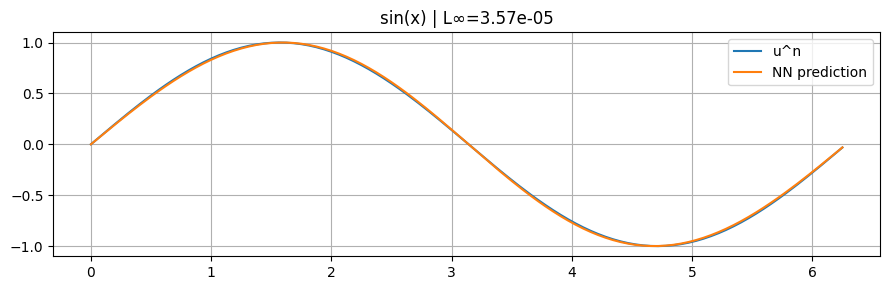

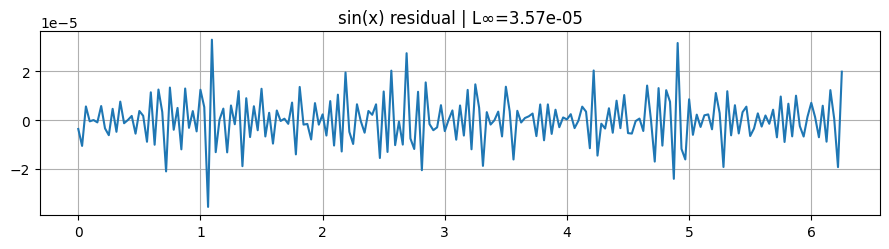

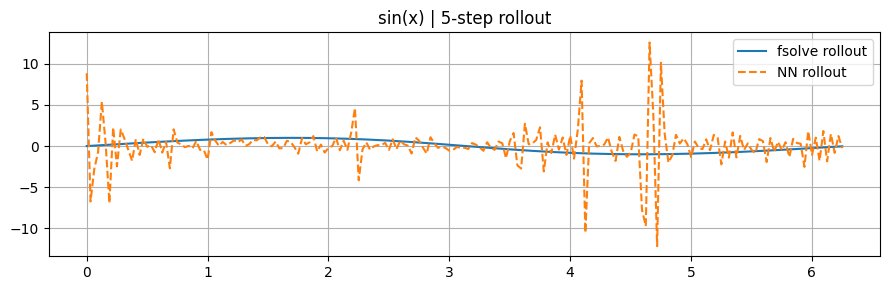


--- cos(14*x) ---
[test] cos(14*x)    | Residual | L∞=1.154e-04 | Mean=2.122e-05


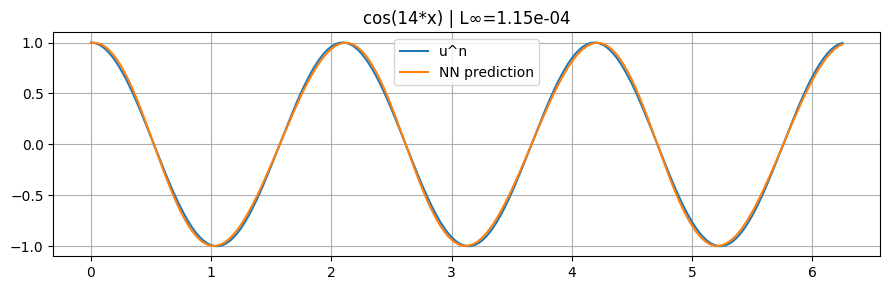

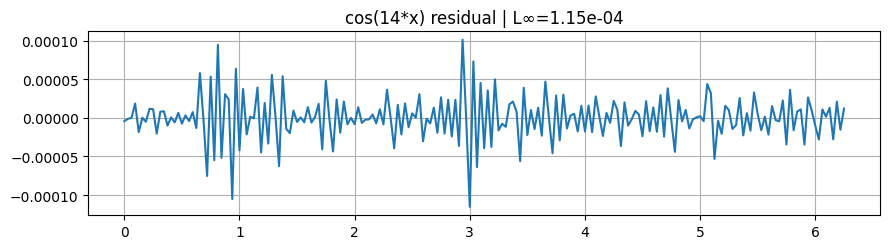

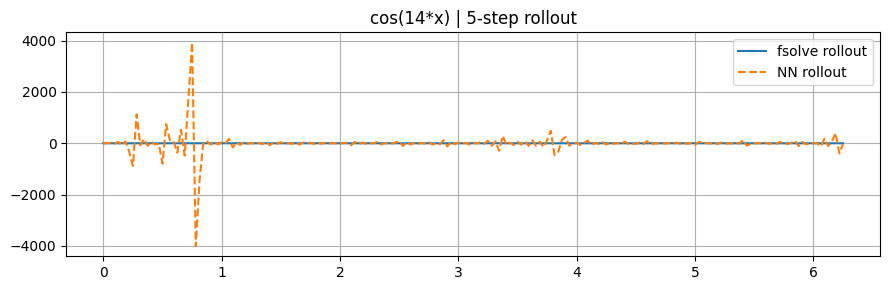


--- sin(x+0.3) ---
[test] sin(x+0.3)   | Residual | L∞=4.027e-05 | Mean=1.008e-05


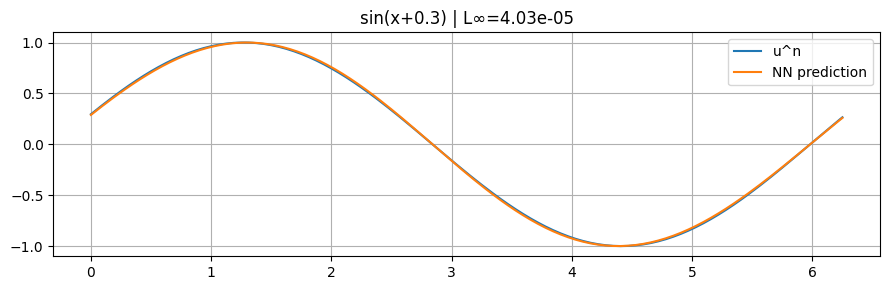

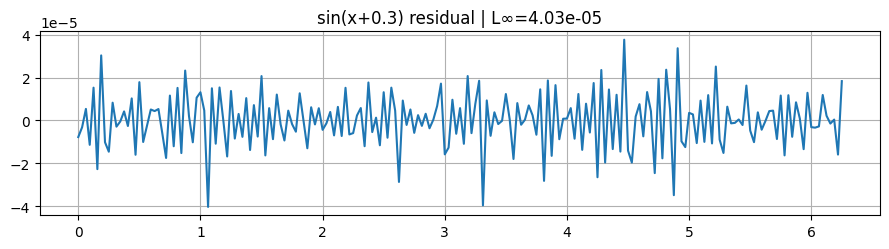

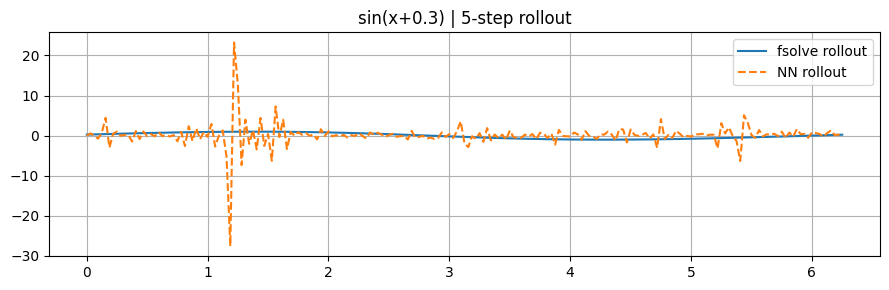


--- sin^2(x) ---
[test] sin^2(x)     | Residual | L∞=6.467e-01 | Mean=1.617e-01


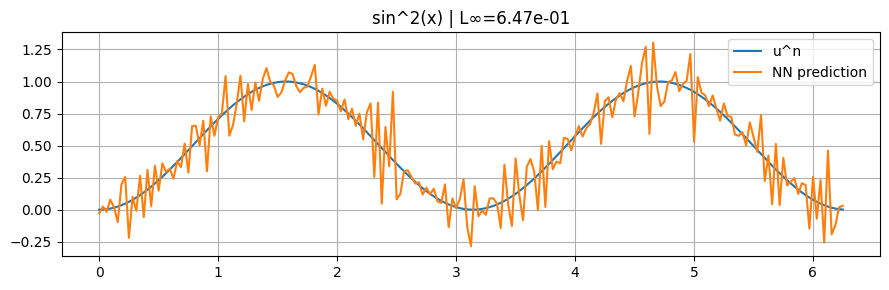

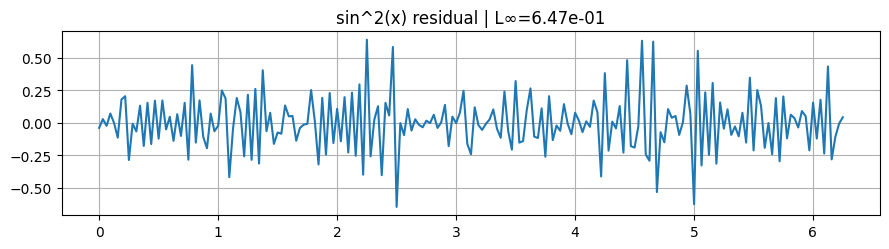

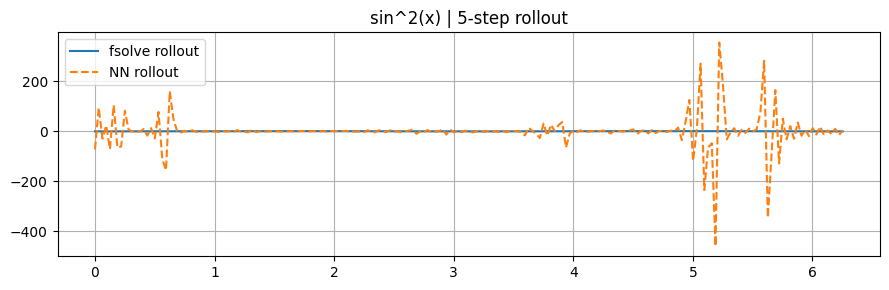


--- cos^3(x) ---
[test] cos^3(x)     | Residual | L∞=2.081e-01 | Mean=4.108e-02


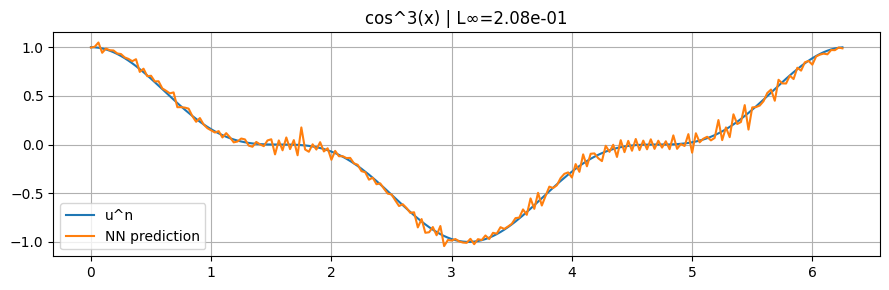

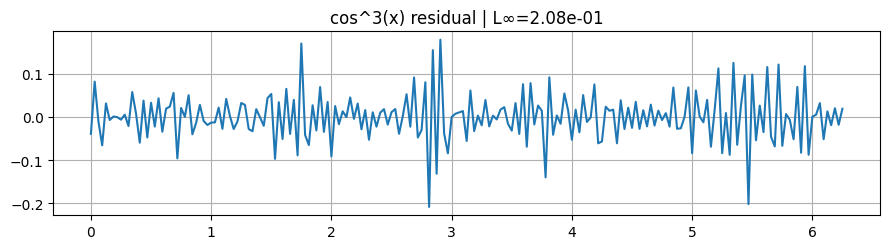

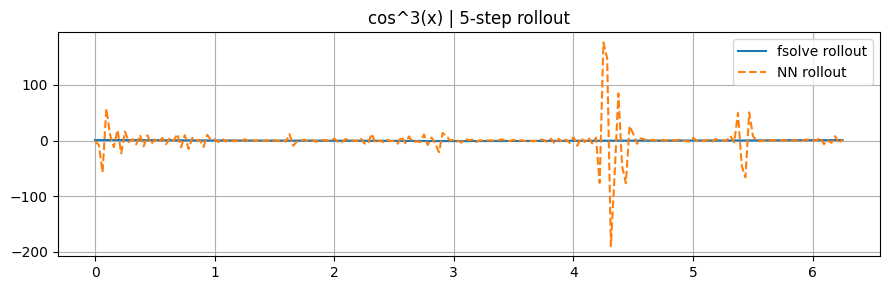


--- sin(2.5x) ---
[test] sin(2.5x)    | Residual | L∞=1.155e-04 | Mean=1.988e-05


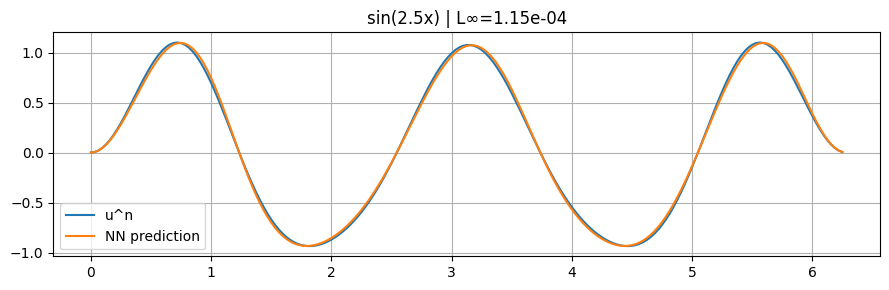

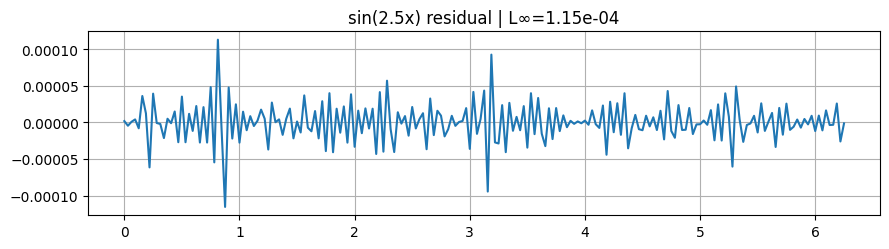

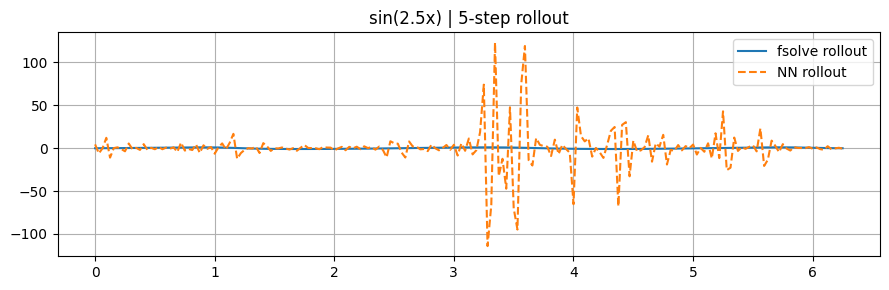


--- sin(x+1.2) ---
[test] sin(x+1.2)   | Residual | L∞=8.179e-05 | Mean=1.765e-05


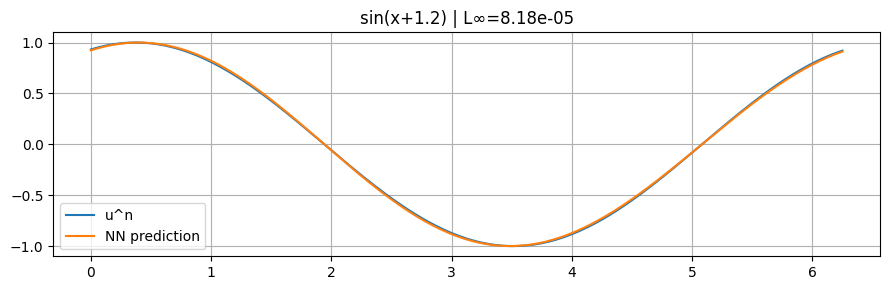

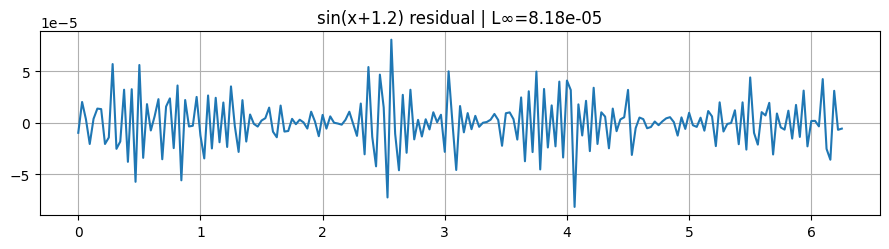

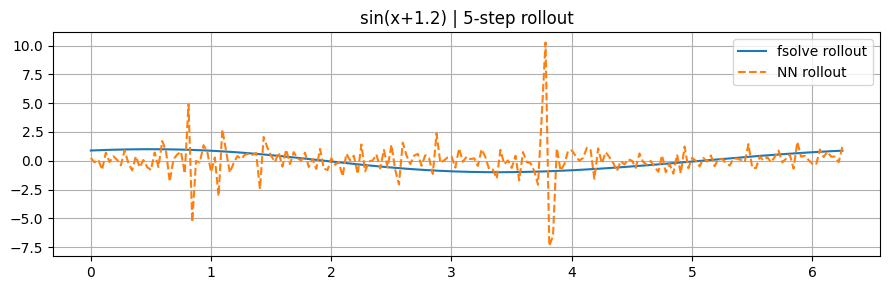

[summary] saved -> pinn_caseD_newton\per_sample_summary_caseD.csv
[plots] saved in -> pinn_caseD_newton\plots

DONE.


In [2]:

import os, warnings, random
import numpy as np
import tensorflow as tf
from scipy.optimize import fsolve, minimize
import matplotlib.pyplot as plt

# CONFIG

TF64 = True
NX_COARSE = 11
NX_FINE   = 201
L = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

EPOCHS = 2500
LR = 5e-5

SUP_WEIGHT  = 1.0
PHYS_WEIGHT = 0.1 / DT   # FIX 1

BETA_L2   = 1e-6
GRAD_CLIP = 1.0
PATIENCE  = 800

CORRECTOR_STEPS = 1

OUT_DIR = "pinn_caseD_newton"
os.makedirs(OUT_DIR, exist_ok=True)
PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(OUT_DIR, "nn_caseD.weights.h5")

if TF64:
    tf.keras.backend.set_floatx('float64')

np.random.seed(42); tf.random.set_seed(42); random.seed(42)


# Spectral differentiation
def generate_D_matrix(Nx, L):
    k = 2*np.pi*1j*np.fft.fftfreq(Nx, d=L/Nx)
    I = np.eye(Nx)
    return np.fft.ifft(k[:,None]*np.fft.fft(I,axis=0),axis=0).real

D_np = generate_D_matrix(NX_FINE, L)
D_tf = tf.constant(D_np, dtype=tf.float64)

def residual_np(y, u):
    return y - u + 0.25*DT*(D_np @ (y**2))

@tf.function
def residual_tf(y, u):
    y_sq = tf.square(y)
    dy_dx = tf.linalg.matmul(y_sq, tf.transpose(D_tf))
    return y - u + 0.25*DT*dy_dx


# grids
x_coarse = np.linspace(0, L, NX_COARSE, endpoint=False)
x_fine   = np.linspace(0, L, NX_FINE, endpoint=False)

def fourier_interpolate(u, Nc, Nf):
    U = np.fft.fftshift(np.fft.fft(u))
    pad = Nf - Nc
    U = np.pad(U, (pad//2, pad-pad//2))
    return (np.fft.ifft(np.fft.ifftshift(U))*Nf/Nc).real


# fsolve

def compute_y1_fsolve(un):
    def F(y): return y - un + 0.25*DT*(D_np @ (y**2))
    def J(y): return np.eye(len(un)) + 0.5*DT*(D_np @ np.diag(y))
    y,_ ,_,_=fsolve(F,un,fprime=J,full_output=True)
    return y


# TRAINING FAMILY

def make_rich_family():
    f=[]

    for k in range(1,13):
        f.append((f"sin({k}x)",lambda x,kk=k:np.sin(kk*x)))
        f.append((f"cos({k}x)",lambda x,kk=k:np.cos(kk*x)))

    # phase
    for k in range(1,6):
        for phi in [0.3,0.7,1.2]:
            f.append((f"sin({k}x+{phi})",
                      lambda x,kk=k,pp=phi:np.sin(kk*x+pp)))

    # fractional
    for k in [1.5,2.5,3.5,4.5]:
        f.append((f"sin({k}x)",lambda x,kk=k:np.sin(kk*x)))

    return f

train_fns = make_rich_family()


# DATA
U=[]; Y=[]
for _,fn in train_fns:
    uc = fn(x_coarse)
    uf = fourier_interpolate(uc, NX_COARSE, NX_FINE)
    U.append(uf)
    Y.append(compute_y1_fsolve(uf))

un_train = np.array(U)
y1_train = np.array(Y)


#  FEATURES
def build_features(U):
    mag = np.abs(np.fft.fft(U,axis=-1))[:,:NX_FINE//2+1]
    mag = 0.2 * mag
    return np.concatenate([U,mag],axis=-1)

X_raw = build_features(un_train)
feat_mean = X_raw.mean(0)
feat_std  = X_raw.std(0) + 1e-12
X_norm = (X_raw - feat_mean)/feat_std

X_tf = tf.constant(X_norm, dtype=tf.float64)
U_tf = tf.constant(un_train, dtype=tf.float64)
Y_tf = tf.constant(y1_train, dtype=tf.float64)


# MODEL
class SineDense(tf.keras.layers.Layer):
    def __init__(self,u,w0=30,is_first=False):
        super().__init__(dtype=tf.float64)
        self.u=u; self.w0=w0; self.f=is_first
    def build(self,s):
        d=int(s[-1])
        b=(1/d) if self.f else np.sqrt(6/d)/self.w0
        self.W=self.add_weight(shape=(d,self.u),
            initializer=tf.random_uniform_initializer(-b,b),dtype=tf.float64)
        self.b=self.add_weight(shape=(self.u,),initializer="zeros",dtype=tf.float64)
    def call(self,x):
        return tf.sin(self.w0*(x@self.W+self.b))

def build_model():
    i=tf.keras.Input(shape=(X_norm.shape[1],),dtype=tf.float64)
    h=SineDense(HIDDEN_UNITS,SIREN_W0,True)(i)
    for _ in range(DEPTH-1):
        h=SineDense(HIDDEN_UNITS,SIREN_W0)(h)
    o=tf.keras.layers.Dense(NX_FINE,dtype=tf.float64)(h)
    return tf.keras.Model(i,o)

model = build_model()
opt = tf.keras.optimizers.Adam(LR)

# TRAIN

print("\n TRAINING CASE D ")

best=np.inf; wait=0

for ep in range(1,EPOCHS+1):
    with tf.GradientTape() as tape:
        y=model(X_tf,training=True)

        sup = tf.reduce_mean(tf.square(y-Y_tf))
        r   = residual_tf(y,U_tf)
        phys= tf.reduce_mean(tf.square(r))

        reg = BETA_L2*tf.add_n([tf.nn.l2_loss(v) for v in model.trainable_variables])

        total = SUP_WEIGHT*sup + PHYS_WEIGHT*phys + reg

    grads = tape.gradient(total,model.trainable_variables)
    grads = [tf.clip_by_norm(g,GRAD_CLIP) for g in grads]
    opt.apply_gradients(zip(grads,model.trainable_variables))

    if ep%100==0 or ep==1:
        print(ep,"total",float(total),"sup",float(sup),"phys",float(phys))

    if total<best:
        best=float(total); wait=0
        model.save_weights(WEIGHTS_FILE)
    else:
        wait+=1
        if wait>PATIENCE: break


# TESTING

print("\n TEST & DIAGNOSTICS (Hybrid + Newton) ")

model.load_weights(WEIGHTS_FILE)
print("[test] loaded Hybrid+Newton weights")

def safe_filename(name):
    return (name.replace("(", "")
                .replace(")", "")
                .replace("*", "")
                .replace("^", "")
                .replace("+", "")
                .replace("-", "")
                .replace(" ", "_"))


# FEATURE BUILDER

def build_feat_single(u_f):
    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]
    mag = 0.2 * mag
    feats = np.concatenate([u_f, mag])
    return ((feats - feat_mean) / feat_std)[None, :]

# NEWTON CORRECTOR

def newton_correct(y, u):
    r = residual_np(y, u)
    J = np.eye(NX_FINE) + 0.5 * DT * (D_np @ np.diag(y))

    try:
        delta = np.linalg.solve(J, r)
    except np.linalg.LinAlgError:
        delta = np.linalg.lstsq(J, r, rcond=None)[0]

    return y - delta

# ROLLOUT

def rollout_nn(u0, steps=5):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(steps):
        feat = build_feat_single(u)
        y = model(tf.constant(feat, dtype=tf.float64),
                  training=False).numpy()[0]
        y_new = newton_correct(y, u)

        # stability limiter (VERY IMPORTANT)
        alpha = 0.5
        y = (1 - alpha)*y + alpha*y_new

        u = y.copy()
        traj.append(u.copy())
    return traj


# TEST FUNCTIONS
tests = [
    ("sin(x)"      , lambda x: np.sin(x)),
    ("cos(14*x)"   , lambda x: np.cos(14*x)),
    ("sin(x+0.3)"  , lambda x: np.sin(x+0.3)),
    ("sin^2(x)"    , lambda x: np.sin(x)**2),
    ("cos^3(x)"    , lambda x: np.cos(x)**3),
    ("sin(2.5x)"   , lambda x: np.sin(2.5*x)),
    ("sin(x+1.2)"  , lambda x: np.sin(x+1.2))
]

summary = {}

# TESTING

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    # initial condition
    uf = fourier_interpolate(fn(x_coarse), NX_COARSE, NX_FINE)

    # NN prediction
    feat = build_feat_single(uf)
    y_pred = model(tf.constant(feat, dtype=tf.float64),
                   training=False).numpy()[0]

    # NEWTON CORRECTION
    y_pred = newton_correct(y_pred, uf)

    # residual
    r = residual_np(y_pred, uf)
    Linf = float(np.max(np.abs(r)))
    Mean = float(np.mean(np.abs(r)))

    print(f"[test] {name:12s} | Residual | L∞={Linf:.3e} | Mean={Mean:.3e}")

    xs = x_fine

    # SOLUTION PLOT
    
    plt.figure(figsize=(9,3))
    plt.plot(xs, uf, label="u^n")
    plt.plot(xs, y_pred, label="NN prediction")
    plt.legend()
    plt.title(f"{name} | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_nn.png"), dpi=150)
    plt.show()

    # RESIDUAL PLOT
    
    plt.figure(figsize=(9,2.6))
    plt.plot(xs, r)
    plt.title(f"{name} residual | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_res.png"), dpi=150)
    plt.show()

    # ROLLOUT
    steps = 5

    traj_nn = rollout_nn(uf, steps)

    traj_fs = [uf.copy()]
    tmp = uf.copy()
    for _ in range(steps):
        tmp = compute_y1_fsolve(tmp)
        traj_fs.append(tmp.copy())

    plt.figure(figsize=(9,3))
    plt.plot(xs, traj_fs[-1], label="fsolve rollout")
    plt.plot(xs, traj_nn[-1], "--", label="NN rollout")
    plt.legend()
    plt.title(f"{name} | {steps}-step rollout")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_rollout.png"), dpi=150)
    plt.show()

    summary[name] = (Linf, Mean)

# SAVE summary

import csv

csv_path = os.path.join(OUT_DIR, "per_sample_summary_caseD.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["name", "Linf", "Mean"])
    for k, v in summary.items():
        w.writerow([k, v[0], v[1]])

print("[summary] saved ->", csv_path)
print("[plots] saved in ->", PLOTS_DIR)

print("\nDONE.")



# Cased (dt=0.005)


 TRAINING CASE D 
1 total 21.21638518045015 sup 1.0088540723648713 phys 1.0103688726525766
100 total 0.026903759869162044 sup 0.0012613374653493083 phys 0.00127445463727511
200 total 0.01426316898447893 sup 0.0006655540709980425 phys 0.0006722200284007629
300 total 0.00849692136573664 sup 0.0003939703196168939 phys 0.0003974914042770977
400 total 0.007123286530324543 sup 0.00032830373405240524 phys 0.00033209721751098655
500 total 0.01203886798644509 sup 0.0005605156343088791 phys 0.0005662696708520613
600 total 0.008881489106868997 sup 0.0004117770229695801 phys 0.00041584152557616843
700 total 0.0030509706433482684 sup 0.00013671502102559086 phys 0.0001380718691609582
800 total 0.00688314091147224 sup 0.0003177967454636707 phys 0.0003206292881386722
900 total 0.0033019926083714336 sup 0.00014844817503260917 phys 0.00015004248769239366
1000 total 0.0035085605343137915 sup 0.00015812408790730981 phys 0.0001598900693996809
1100 total 0.004036267124466532 sup 0.00018292876076982011 phys

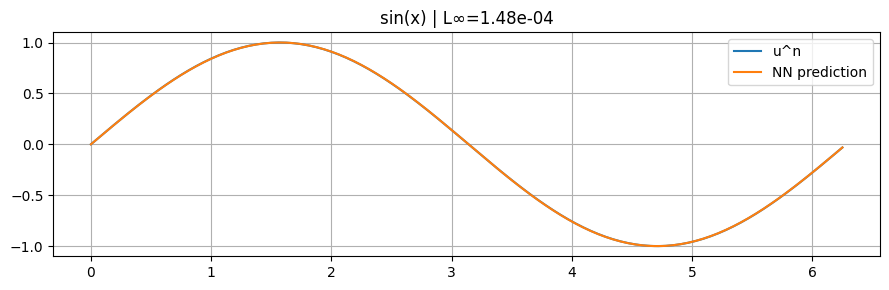

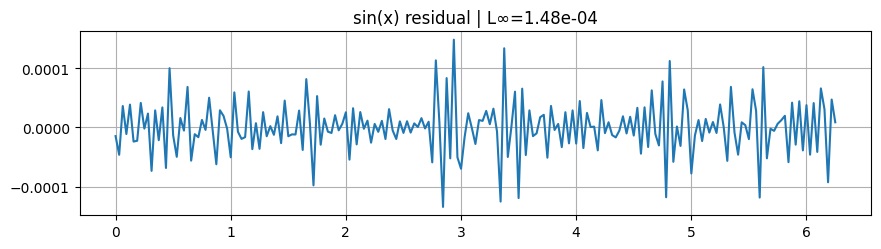

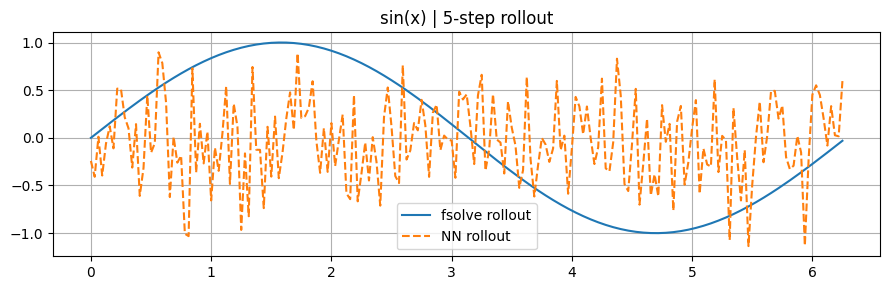


--- cos(14*x) ---
[test] cos(14*x)    | Residual | L∞=2.342e-04 | Mean=5.039e-05


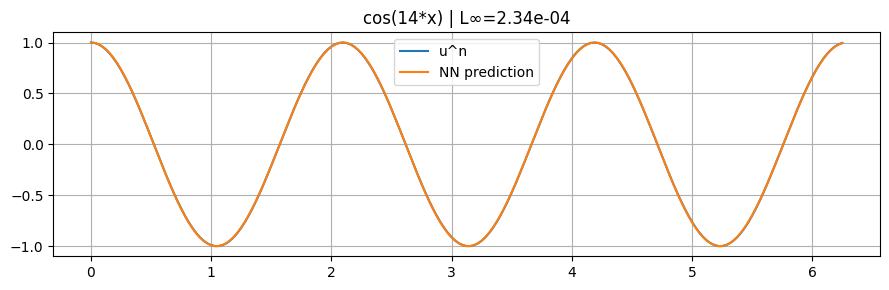

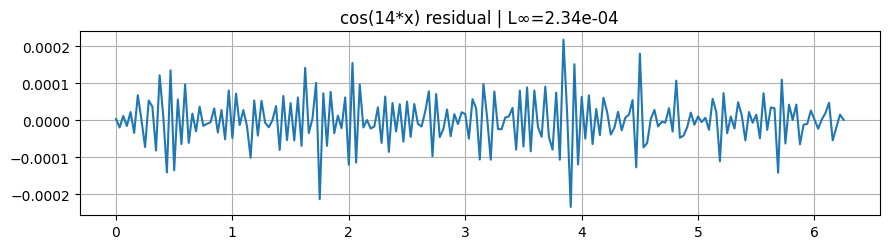

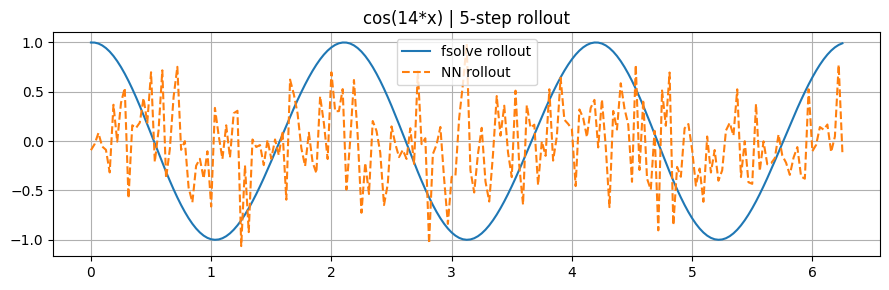


--- sin(x+0.3) ---
[test] sin(x+0.3)   | Residual | L∞=2.437e-04 | Mean=3.752e-05


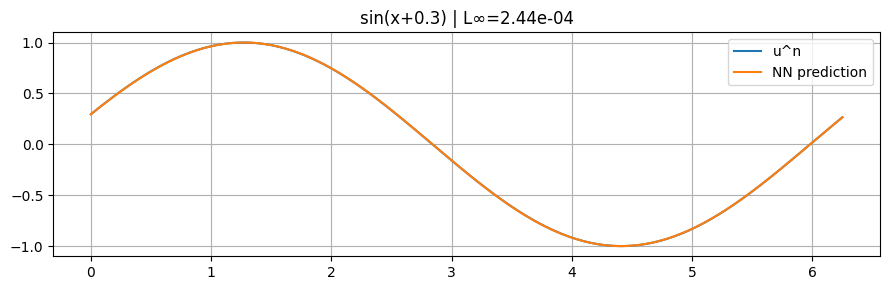

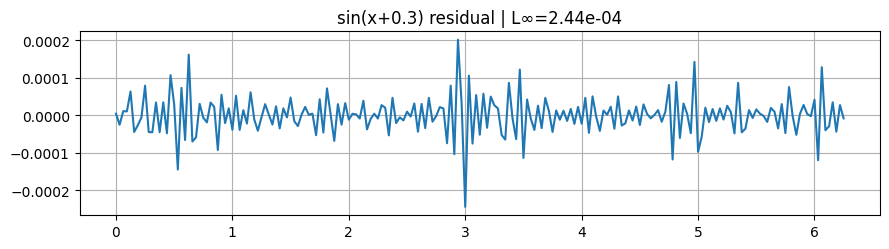

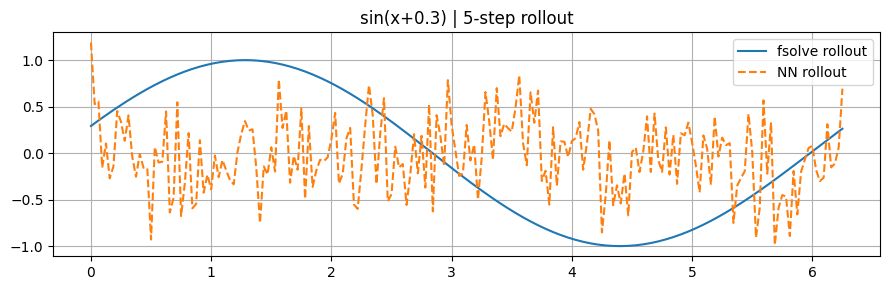


--- sin^2(x) ---
[test] sin^2(x)     | Residual | L∞=1.244e-01 | Mean=1.709e-02


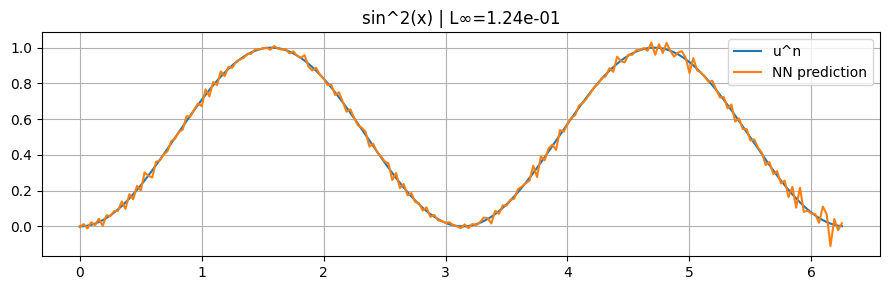

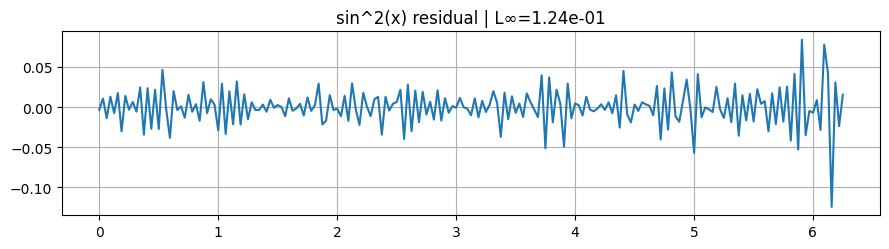

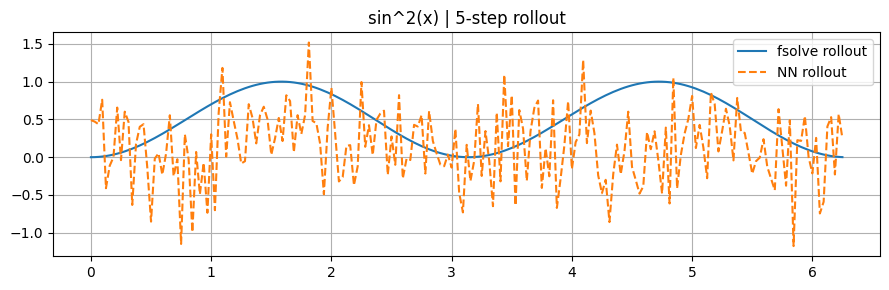


--- cos^3(x) ---
[test] cos^3(x)     | Residual | L∞=1.894e-02 | Mean=4.374e-03


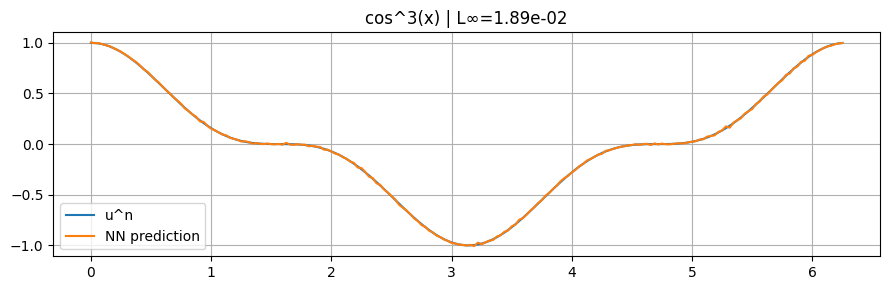

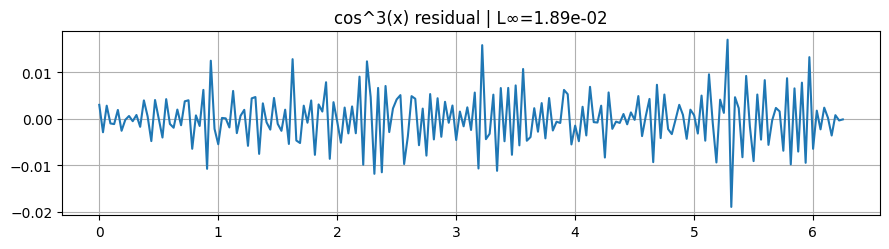

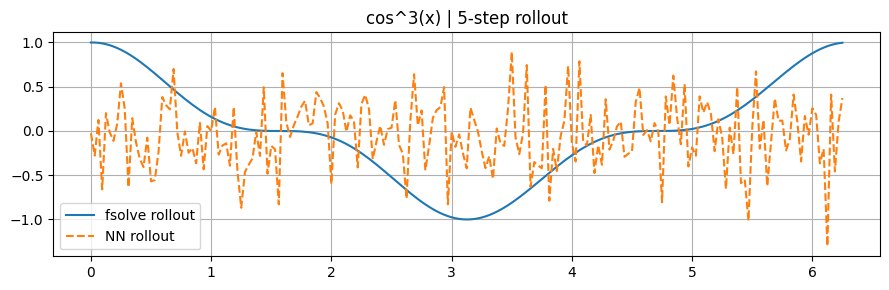


--- sin(2.5x) ---
[test] sin(2.5x)    | Residual | L∞=2.955e-04 | Mean=4.080e-05


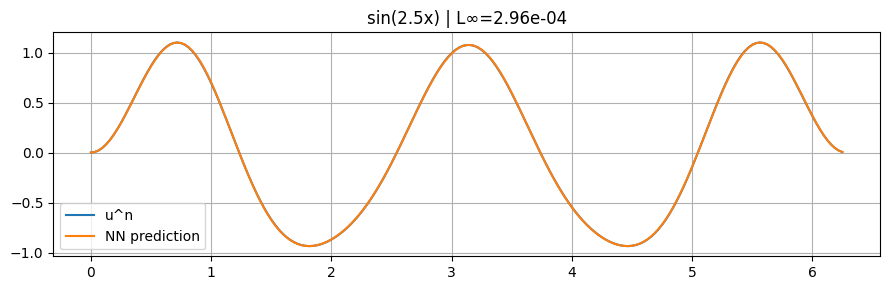

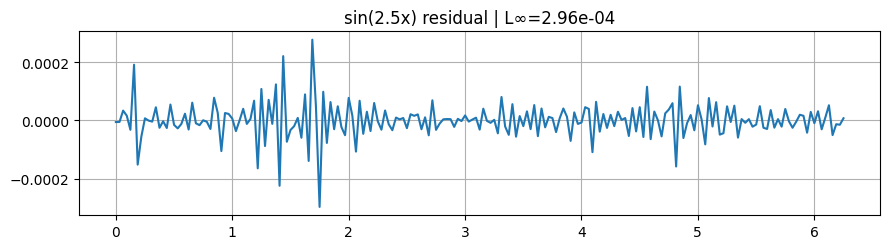

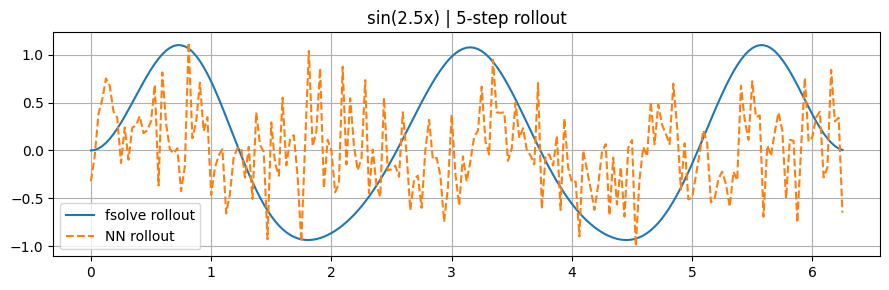


--- sin(x+1.2) ---
[test] sin(x+1.2)   | Residual | L∞=1.765e-04 | Mean=4.041e-05


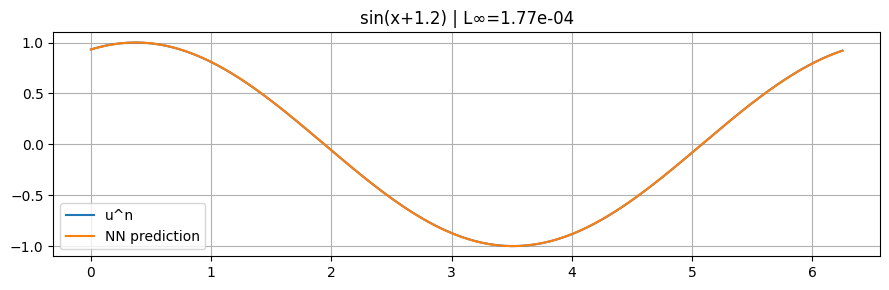

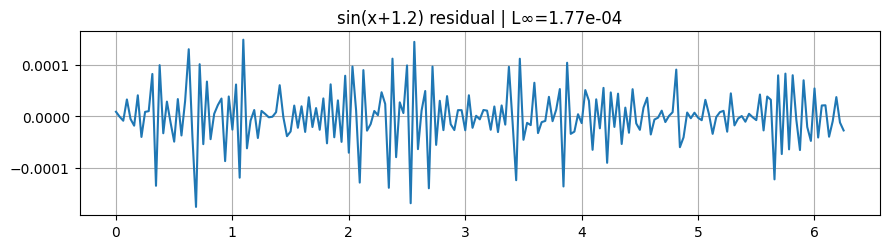

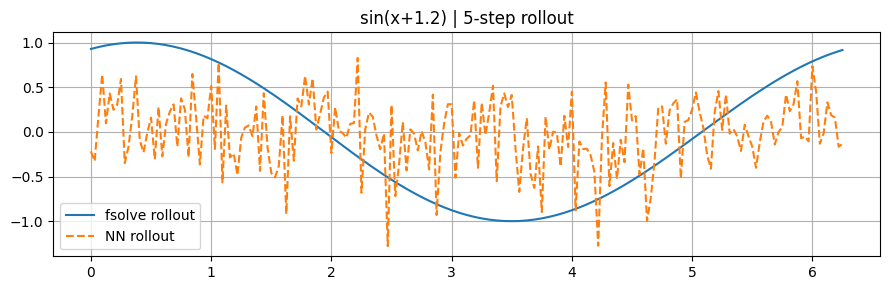

[summary] saved -> pinn_caseD_newton\per_sample_summary_caseD.csv
[plots] saved in -> pinn_caseD_newton\plots

DONE.


In [3]:

import os, warnings, random
import numpy as np
import tensorflow as tf
from scipy.optimize import fsolve, minimize
import matplotlib.pyplot as plt

# CONFIG

TF64 = True
NX_COARSE = 11
NX_FINE   = 201
L = 2*np.pi
DT = 0.005

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

EPOCHS = 2500
LR = 5e-5

SUP_WEIGHT  = 1.0
PHYS_WEIGHT = 0.1 / DT   # FIX 1

BETA_L2   = 1e-6
GRAD_CLIP = 1.0
PATIENCE  = 800

CORRECTOR_STEPS = 1

OUT_DIR = "pinn_caseD_newton"
os.makedirs(OUT_DIR, exist_ok=True)
PLOTS_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(OUT_DIR, "nn_caseD.weights.h5")

if TF64:
    tf.keras.backend.set_floatx('float64')

np.random.seed(42); tf.random.set_seed(42); random.seed(42)


# Spectral differentiation
def generate_D_matrix(Nx, L):
    k = 2*np.pi*1j*np.fft.fftfreq(Nx, d=L/Nx)
    I = np.eye(Nx)
    return np.fft.ifft(k[:,None]*np.fft.fft(I,axis=0),axis=0).real

D_np = generate_D_matrix(NX_FINE, L)
D_tf = tf.constant(D_np, dtype=tf.float64)

def residual_np(y, u):
    return y - u + 0.25*DT*(D_np @ (y**2))

@tf.function
def residual_tf(y, u):
    y_sq = tf.square(y)
    dy_dx = tf.linalg.matmul(y_sq, tf.transpose(D_tf))
    return y - u + 0.25*DT*dy_dx


# grids
x_coarse = np.linspace(0, L, NX_COARSE, endpoint=False)
x_fine   = np.linspace(0, L, NX_FINE, endpoint=False)

def fourier_interpolate(u, Nc, Nf):
    U = np.fft.fftshift(np.fft.fft(u))
    pad = Nf - Nc
    U = np.pad(U, (pad//2, pad-pad//2))
    return (np.fft.ifft(np.fft.ifftshift(U))*Nf/Nc).real


# fsolve

def compute_y1_fsolve(un):
    def F(y): return y - un + 0.25*DT*(D_np @ (y**2))
    def J(y): return np.eye(len(un)) + 0.5*DT*(D_np @ np.diag(y))
    y,_ ,_,_=fsolve(F,un,fprime=J,full_output=True)
    return y


# TRAINING FAMILY

def make_rich_family():
    f=[]

    for k in range(1,13):
        f.append((f"sin({k}x)",lambda x,kk=k:np.sin(kk*x)))
        f.append((f"cos({k}x)",lambda x,kk=k:np.cos(kk*x)))

    # phase
    for k in range(1,6):
        for phi in [0.3,0.7,1.2]:
            f.append((f"sin({k}x+{phi})",
                      lambda x,kk=k,pp=phi:np.sin(kk*x+pp)))

    # fractional
    for k in [1.5,2.5,3.5,4.5]:
        f.append((f"sin({k}x)",lambda x,kk=k:np.sin(kk*x)))

    return f

train_fns = make_rich_family()


# DATA
U=[]; Y=[]
for _,fn in train_fns:
    uc = fn(x_coarse)
    uf = fourier_interpolate(uc, NX_COARSE, NX_FINE)
    U.append(uf)
    Y.append(compute_y1_fsolve(uf))

un_train = np.array(U)
y1_train = np.array(Y)


#  FEATURES
def build_features(U):
    mag = np.abs(np.fft.fft(U,axis=-1))[:,:NX_FINE//2+1]
    mag = 0.2 * mag
    return np.concatenate([U,mag],axis=-1)

X_raw = build_features(un_train)
feat_mean = X_raw.mean(0)
feat_std  = X_raw.std(0) + 1e-12
X_norm = (X_raw - feat_mean)/feat_std

X_tf = tf.constant(X_norm, dtype=tf.float64)
U_tf = tf.constant(un_train, dtype=tf.float64)
Y_tf = tf.constant(y1_train, dtype=tf.float64)


# MODEL
class SineDense(tf.keras.layers.Layer):
    def __init__(self,u,w0=30,is_first=False):
        super().__init__(dtype=tf.float64)
        self.u=u; self.w0=w0; self.f=is_first
    def build(self,s):
        d=int(s[-1])
        b=(1/d) if self.f else np.sqrt(6/d)/self.w0
        self.W=self.add_weight(shape=(d,self.u),
            initializer=tf.random_uniform_initializer(-b,b),dtype=tf.float64)
        self.b=self.add_weight(shape=(self.u,),initializer="zeros",dtype=tf.float64)
    def call(self,x):
        return tf.sin(self.w0*(x@self.W+self.b))

def build_model():
    i=tf.keras.Input(shape=(X_norm.shape[1],),dtype=tf.float64)
    h=SineDense(HIDDEN_UNITS,SIREN_W0,True)(i)
    for _ in range(DEPTH-1):
        h=SineDense(HIDDEN_UNITS,SIREN_W0)(h)
    o=tf.keras.layers.Dense(NX_FINE,dtype=tf.float64)(h)
    return tf.keras.Model(i,o)

model = build_model()
opt = tf.keras.optimizers.Adam(LR)

# TRAIN

print("\n TRAINING CASE D ")

best=np.inf; wait=0

for ep in range(1,EPOCHS+1):
    with tf.GradientTape() as tape:
        y=model(X_tf,training=True)

        sup = tf.reduce_mean(tf.square(y-Y_tf))
        r   = residual_tf(y,U_tf)
        phys= tf.reduce_mean(tf.square(r))

        reg = BETA_L2*tf.add_n([tf.nn.l2_loss(v) for v in model.trainable_variables])

        total = SUP_WEIGHT*sup + PHYS_WEIGHT*phys + reg

    grads = tape.gradient(total,model.trainable_variables)
    grads = [tf.clip_by_norm(g,GRAD_CLIP) for g in grads]
    opt.apply_gradients(zip(grads,model.trainable_variables))

    if ep%100==0 or ep==1:
        print(ep,"total",float(total),"sup",float(sup),"phys",float(phys))

    if total<best:
        best=float(total); wait=0
        model.save_weights(WEIGHTS_FILE)
    else:
        wait+=1
        if wait>PATIENCE: break


# TESTING

print("\n TEST & DIAGNOSTICS (Hybrid + Newton) ")

model.load_weights(WEIGHTS_FILE)
print("[test] loaded Hybrid+Newton weights")

def safe_filename(name):
    return (name.replace("(", "")
                .replace(")", "")
                .replace("*", "")
                .replace("^", "")
                .replace("+", "")
                .replace("-", "")
                .replace(" ", "_"))


# FEATURE BUILDER

def build_feat_single(u_f):
    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]
    mag = 0.2 * mag
    feats = np.concatenate([u_f, mag])
    return ((feats - feat_mean) / feat_std)[None, :]

# NEWTON CORRECTOR

def newton_correct(y, u):
    r = residual_np(y, u)
    J = np.eye(NX_FINE) + 0.5 * DT * (D_np @ np.diag(y))

    try:
        delta = np.linalg.solve(J, r)
    except np.linalg.LinAlgError:
        delta = np.linalg.lstsq(J, r, rcond=None)[0]

    return y - delta

# ROLLOUT

def rollout_nn(u0, steps=5):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(steps):
        feat = build_feat_single(u)
        y = model(tf.constant(feat, dtype=tf.float64),
                  training=False).numpy()[0]
        y_new = newton_correct(y, u)

        # stability limiter (VERY IMPORTANT)
        alpha = 0.5
        y = (1 - alpha)*y + alpha*y_new

        u = y.copy()
        traj.append(u.copy())
    return traj


# TEST FUNCTIONS
tests = [
    ("sin(x)"      , lambda x: np.sin(x)),
    ("cos(14*x)"   , lambda x: np.cos(14*x)),
    ("sin(x+0.3)"  , lambda x: np.sin(x+0.3)),
    ("sin^2(x)"    , lambda x: np.sin(x)**2),
    ("cos^3(x)"    , lambda x: np.cos(x)**3),
    ("sin(2.5x)"   , lambda x: np.sin(2.5*x)),
    ("sin(x+1.2)"  , lambda x: np.sin(x+1.2))
]

summary = {}

# TESTING

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    # initial condition
    uf = fourier_interpolate(fn(x_coarse), NX_COARSE, NX_FINE)

    # NN prediction
    feat = build_feat_single(uf)
    y_pred = model(tf.constant(feat, dtype=tf.float64),
                   training=False).numpy()[0]

    # NEWTON CORRECTION
    y_pred = newton_correct(y_pred, uf)

    # residual
    r = residual_np(y_pred, uf)
    Linf = float(np.max(np.abs(r)))
    Mean = float(np.mean(np.abs(r)))

    print(f"[test] {name:12s} | Residual | L∞={Linf:.3e} | Mean={Mean:.3e}")

    xs = x_fine

    # SOLUTION PLOT
    
    plt.figure(figsize=(9,3))
    plt.plot(xs, uf, label="u^n")
    plt.plot(xs, y_pred, label="NN prediction")
    plt.legend()
    plt.title(f"{name} | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_nn.png"), dpi=150)
    plt.show()

    # RESIDUAL PLOT
    
    plt.figure(figsize=(9,2.6))
    plt.plot(xs, r)
    plt.title(f"{name} residual | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_res.png"), dpi=150)
    plt.show()

    # ROLLOUT
    steps = 5

    traj_nn = rollout_nn(uf, steps)

    traj_fs = [uf.copy()]
    tmp = uf.copy()
    for _ in range(steps):
        tmp = compute_y1_fsolve(tmp)
        traj_fs.append(tmp.copy())

    plt.figure(figsize=(9,3))
    plt.plot(xs, traj_fs[-1], label="fsolve rollout")
    plt.plot(xs, traj_nn[-1], "--", label="NN rollout")
    plt.legend()
    plt.title(f"{name} | {steps}-step rollout")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{safe_name}_rollout.png"), dpi=150)
    plt.show()

    summary[name] = (Linf, Mean)

# SAVE summary

import csv

csv_path = os.path.join(OUT_DIR, "per_sample_summary_caseD.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["name", "Linf", "Mean"])
    for k, v in summary.items():
        w.writerow([k, v[0], v[1]])

print("[summary] saved ->", csv_path)
print("[plots] saved in ->", PLOTS_DIR)

print("\nDONE.")